# NB04 — Modelling
**Camino de Santiago — Contextual Drivers of Pilgrim Flow Mutations (2003–2025)**

Fits interpretable regression models (Ridge / Lasso) for each of the 7 NB04 targets.

| | |
|---|---|
| **Input** | `data/processed/features_nb03.csv` |
| **CV strategy** | Time-series forward walk (`TimeSeriesSplit`) |
| **Max features/model** | 4–5 (overfitting guard, n=21) |
| **Baseline** | Linear trend on `year` only (R² reference) |
| **Output** | `reports/NB04_results.csv` + figures |

## 0 · Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from sklearn.linear_model import RidgeCV, LassoCV, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score, mean_absolute_error

ROOT      = Path('..').resolve()
PROCESSED = ROOT / 'data' / 'processed'
FIGURES   = ROOT / 'figures'
REPORTS   = ROOT / 'reports'
for p in [FIGURES, REPORTS]: p.mkdir(parents=True, exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')
plt.rcParams['figure.dpi'] = 120

matrix = pd.read_csv(PROCESSED / 'features_nb03.csv', index_col='year').sort_index()
years  = matrix.index.values

TARGETS = [
    'share_Camino_Portugues_Costa',
    'share_Camino_Frances',
    'total_pilgrims',
    'pct_women',
    'diversity_core',
    'share_Via_de_la_Plata',
    'share_challenge',
]

ALPHA_GRID = np.logspace(-3, 3, 100)

print('Setup OK')
print(f'Matrix: {matrix.shape}  |  years {years.min()}–{years.max()}')

Setup OK
Matrix: (21, 42)  |  years 2004–2024


## 1 · Modelling framework

### Design choices

**n=21 constraint** — with at most 21 observations, models are kept deliberately simple: max 4–5 features, regularised estimators only. VIF is not calculable (n < p in full feature space) — multicollinearity is handled by Ridge/Lasso shrinkage instead.

**Detrending policy** — common trend confound is real for Axis B signals (NB02 §4.2). When `detrend=True`, `_dt` versions replace raw features where available. Targets with strong structural trends (`pct_women`, `total_pilgrims`) are also detrended before fitting.

**Cross-validation** — `TimeSeriesSplit` forward walk. `n_splits=4` for full-window models (n≈19), `n_splits=3` for trail-dependent models (n≈10, Trail SJ 2013–2024).

**Alpha selection** — `RidgeCV` / `LassoCV` on the CV folds. Final coefficients are refitted on the full sample for interpretability.

In [2]:
def get_features(candidates: list, detrend: bool) -> list:
    """Return detrended version of each feature if available and detrend=True."""
    if not detrend:
        return candidates
    return [f'{c}_dt' if f'{c}_dt' in matrix.columns else c for c in candidates]


def run_model(target: str, candidates: list, detrend: bool = False,
              n_splits: int = 4) -> dict:
    """
    Fit Ridge and Lasso on `candidates` predicting `target`.
    Returns a results dict with metrics and coefficients.
    """
    feats = get_features(candidates, detrend)
    cols  = [target] + feats
    data  = matrix[cols].dropna().copy()
    X     = data[feats].values
    y     = data[target].values
    idx   = data.index.values
    n     = len(data)

    if n < 8:
        print(f'  ⚠ {target}: only {n} complete obs — skipping')
        return None

    tscv = TimeSeriesSplit(n_splits=min(n_splits, n // 3))
    scaler = StandardScaler()

    # ── Ridge ──────────────────────────────────────────────────────────────────
    ridge_cv = RidgeCV(alphas=ALPHA_GRID, cv=tscv)
    ridge_cv.fit(scaler.fit_transform(X), y)

    # ── Lasso ──────────────────────────────────────────────────────────────────
    lasso_cv = LassoCV(alphas=ALPHA_GRID, cv=tscv, max_iter=10000)
    lasso_cv.fit(scaler.fit_transform(X), y)

    # ── Full-sample refit for interpretable coefficients ───────────────────────
    Xs = scaler.fit_transform(X)
    from sklearn.linear_model import Ridge, Lasso
    ridge_final = Ridge(alpha=ridge_cv.alpha_).fit(Xs, y)
    lasso_final = Lasso(alpha=lasso_cv.alpha_, max_iter=10000).fit(Xs, y)

    y_hat_ridge = ridge_final.predict(Xs)
    y_hat_lasso = lasso_final.predict(Xs)

    return {
        'target'      : target,
        'features'    : feats,
        'n'           : n,
        'detrend'     : detrend,
        'ridge_alpha' : round(ridge_cv.alpha_, 4),
        'lasso_alpha' : round(lasso_cv.alpha_, 4),
        'ridge_r2'    : round(r2_score(y, y_hat_ridge), 3),
        'lasso_r2'    : round(r2_score(y, y_hat_lasso), 3),
        'ridge_mae'   : round(mean_absolute_error(y, y_hat_ridge), 4),
        'lasso_mae'   : round(mean_absolute_error(y, y_hat_lasso), 4),
        'ridge_coef'  : dict(zip(feats, ridge_final.coef_.round(4))),
        'lasso_coef'  : dict(zip(feats, lasso_final.coef_.round(4))),
        'y'           : y,
        'y_hat_ridge' : y_hat_ridge,
        'y_hat_lasso' : y_hat_lasso,
        'index'       : idx,
    }


def plot_model(res: dict, ax_ridge=None, ax_lasso=None):
    """Plot actual vs predicted for Ridge and Lasso side by side."""
    if res is None: return
    for ax, label, y_hat, r2 in [
        (ax_ridge, 'Ridge', res['y_hat_ridge'], res['ridge_r2']),
        (ax_lasso, 'Lasso', res['y_hat_lasso'], res['lasso_r2']),
    ]:
        if ax is None: continue
        ax.plot(res['index'], res['y'],     'o-', lw=2,   label='Actual')
        ax.plot(res['index'], y_hat,        's--', lw=1.5, label=f'{label} fit')
        ax.set_title(f"{label}  R²={r2}  α={res[f'{label.lower()}_alpha']}")
        ax.legend(fontsize=8)


def print_coefs(res: dict):
    """Print Ridge and Lasso coefficients side by side."""
    if res is None: return
    ridge_c = res['ridge_coef']
    lasso_c = res['lasso_coef']
    print(f"{'Feature':<45} {'Ridge':>8}  {'Lasso':>8}")
    print('-' * 65)
    for f in res['features']:
        r = ridge_c.get(f, 0)
        l = lasso_c.get(f, 0)
        flag = '  ← zeroed' if l == 0 else ''
        print(f"  {f:<43} {r:>8.4f}  {l:>8.4f}{flag}")
    print(f"\n  n={res['n']}  detrend={res['detrend']}")
    print(f"  Ridge  R²={res['ridge_r2']}  MAE={res['ridge_mae']}")
    print(f"  Lasso  R²={res['lasso_r2']}  MAE={res['lasso_mae']}")

print('Framework OK')

Framework OK


## 2 · Naïve baseline — linear trend only

R² obtained by regressing each target on `year` alone. Any contextual model must beat this threshold to demonstrate that its features add information beyond pure time trend. On n=21, a high baseline R² is expected for trending series — this makes it a conservative benchmark, not an easy one.

In [3]:
baseline_results = {}

for target in TARGETS:
    y   = matrix[target].dropna().values
    x   = matrix[target].dropna().index.values.reshape(-1, 1).astype(float)
    lr  = LinearRegression().fit(x, y)
    r2  = round(r2_score(y, lr.predict(x)), 3)
    baseline_results[target] = r2

baseline_df = pd.Series(baseline_results, name='baseline_R2').to_frame()
print('── Baseline R² (linear trend on year only) ─────────────────────────────')
print(baseline_df.to_string())
print('\nAny contextual model must exceed these values to justify its features.')

── Baseline R² (linear trend on year only) ─────────────────────────────
                              baseline_R2
share_Camino_Portugues_Costa        0.715
share_Camino_Frances                0.938
total_pilgrims                      0.508
pct_women                           0.901
diversity_core                      0.943
share_Via_de_la_Plata               0.663
share_challenge                     0.236

Any contextual model must exceed these values to justify its features.


## 3 · Target 1 — `share_Camino_Portugues_Costa`

**Priority 1 · Strongest growth signal in the dataset.**

**Feature selection rationale:**
- `accessibility_routes_share` excluded (r=0.99 — near-tautology: P.Costa ≈ 80% of cluster)
- `trends_FR_lag0_dt` (r=0.85): French media interest as concurrent indicator
- `trends_PT_lag2_dt` (r=0.70): Portuguese interest with 2-year lead — word-of-mouth + flight route expansion hypothesis
- `trail_countries_lag1_dt` (r=0.83): global reach of Trail SJ as awareness proxy
- `deferred_demand` (r=0.92): post-COVID acceleration amplifier

**Detrending:** YES — target has strong structural upward trend (2018 inflection confirmed by PELT).

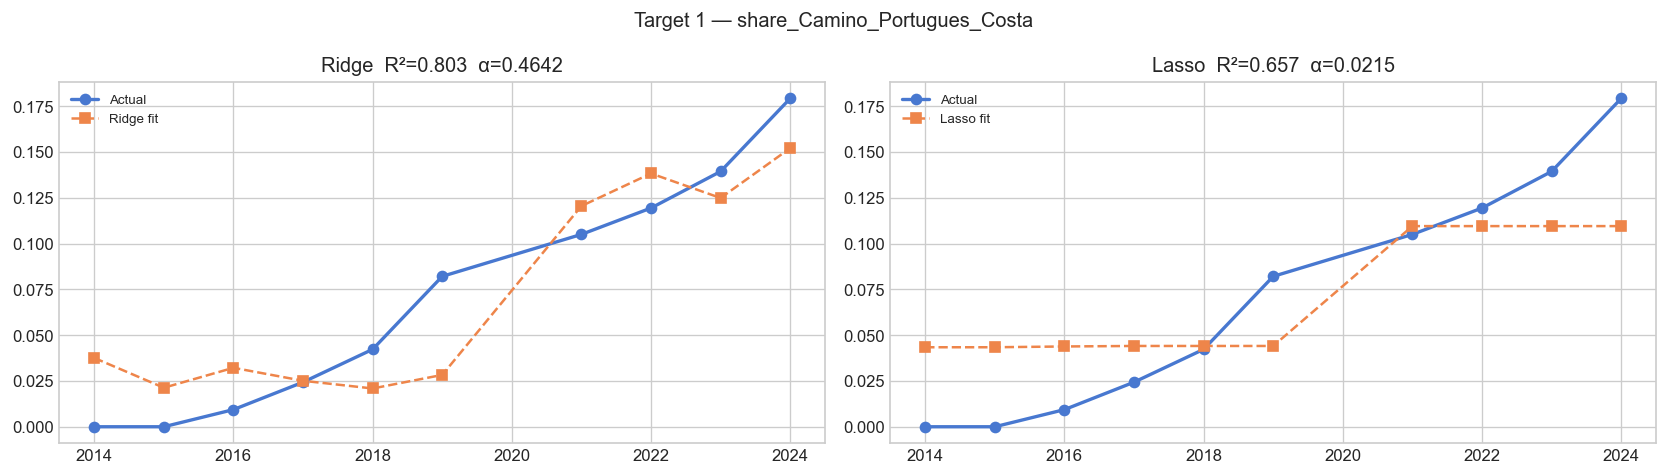

Feature                                          Ridge     Lasso
-----------------------------------------------------------------
  trends_FR_lag0_dt                            -0.0087    0.0000  ← zeroed
  trends_PT_lag2_dt                            -0.0058   -0.0000  ← zeroed
  trail_countries_lag1_dt                      -0.0030    0.0000  ← zeroed
  deferred_demand                               0.0350    0.0322
  ratio_sequential_dt                          -0.0202   -0.0000  ← zeroed

  n=10  detrend=True
  Ridge  R²=0.803  MAE=0.0234
  Lasso  R²=0.657  MAE=0.0295


In [4]:
CANDS_T1 = [
    'trends_FR_lag0',
    'trends_PT_lag2',
    'trail_countries_lag1',
    'deferred_demand',
    'ratio_sequential',
]

res_t1 = run_model('share_Camino_Portugues_Costa', CANDS_T1, detrend=True, n_splits=4)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Target 1 — share_Camino_Portugues_Costa', fontsize=12)
plot_model(res_t1, axes[0], axes[1])
plt.tight_layout()
plt.savefig(FIGURES / 'NB04_T1_p_costa.png', dpi=150)
plt.show()

print_coefs(res_t1)

## 4 · Target 2 — `share_Camino_Frances`

**Priority 2 · Dominant route — structural decline in relative share.**

**Feature selection rationale:**
- `diversity_core` excluded (r=−0.99 — mechanically linked: Francés share ≈ 1 − diversity)
- `trends_FR_lag0_dt` (r=−0.92): rising French interest → crowd-avoidance migration
- `trends_PT_lag2_dt` (r=−0.91): Portuguese route growth cannibalises Francés share
- `ratio_sequential_dt` (r=−0.93): staged pilgrims are Francés walkers — declining proxy
- `phase_regime`: structural phase captures the 2010–2017 → 2018+ regime shift

**Detrending:** YES — strong downward trend in share from 2010 onward.

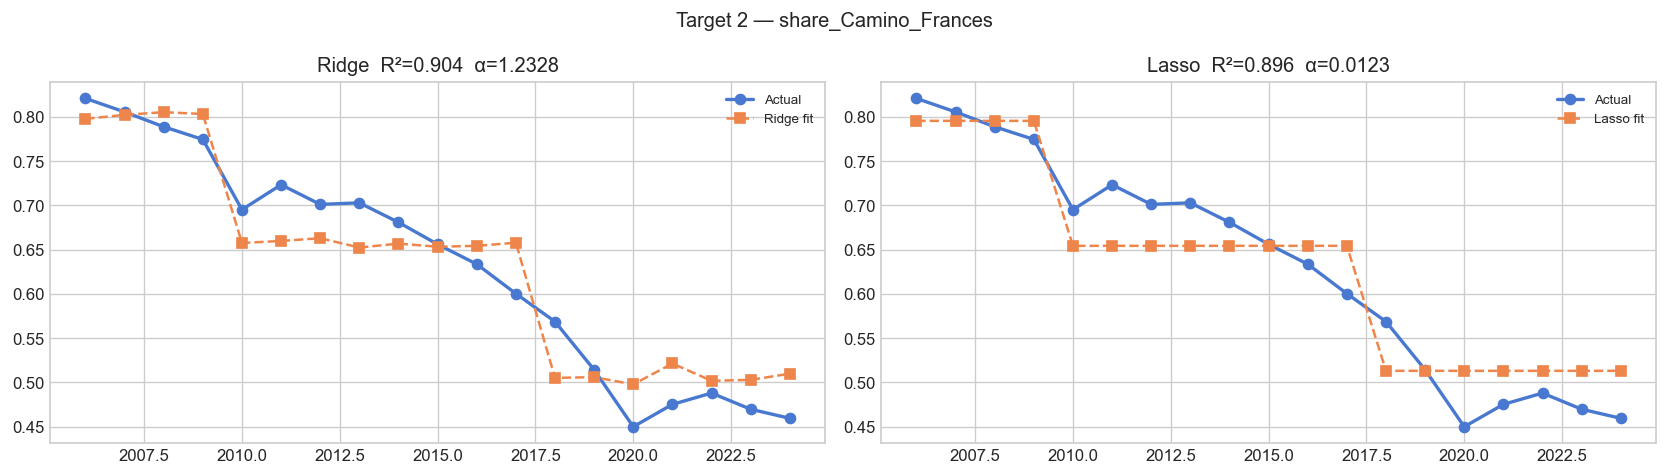

Feature                                          Ridge     Lasso
-----------------------------------------------------------------
  trends_FR_lag0_dt                            -0.0002   -0.0000  ← zeroed
  trends_PT_lag2_dt                             0.0044    0.0000  ← zeroed
  ratio_sequential_dt                          -0.0010   -0.0000  ← zeroed
  trends_KR_lag1_dt                            -0.0042   -0.0000  ← zeroed
  phase_regime                                 -0.1099   -0.1051

  n=19  detrend=True
  Ridge  R²=0.904  MAE=0.0332
  Lasso  R²=0.896  MAE=0.0343


In [5]:
CANDS_T2 = [
    'trends_FR_lag0',
    'trends_PT_lag2',
    'ratio_sequential',
    'trends_KR_lag1',
    'phase_regime',
]

res_t2 = run_model('share_Camino_Frances', CANDS_T2, detrend=True, n_splits=4)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Target 2 — share_Camino_Frances', fontsize=12)
plot_model(res_t2, axes[0], axes[1])
plt.tight_layout()
plt.savefig(FIGURES / 'NB04_T2_frances.png', dpi=150)
plt.show()

print_coefs(res_t2)

## 5 · Target 3 — `total_pilgrims`

**Priority 3 · System-level prediction.**

**Feature selection rationale:**
- `yoy_growth_lag1`: autoregressive component — momentum inertia
- `holy_year`: binary event with documented ×1.3–1.5 amplification effect (NB02 §4.4)
- `deferred_demand`: cumulative deficit proxy — post-COVID recovery driver
- `trail_countries_lag1_dt` (r=0.76): global reach as leading indicator
- `post_covid_regime`: structural plateau shift from 2022

**Detrending:** NO for binary/event features. YES for trail_countries (common trend). Target itself is NOT detrended — absolute volume is the modelling objective.

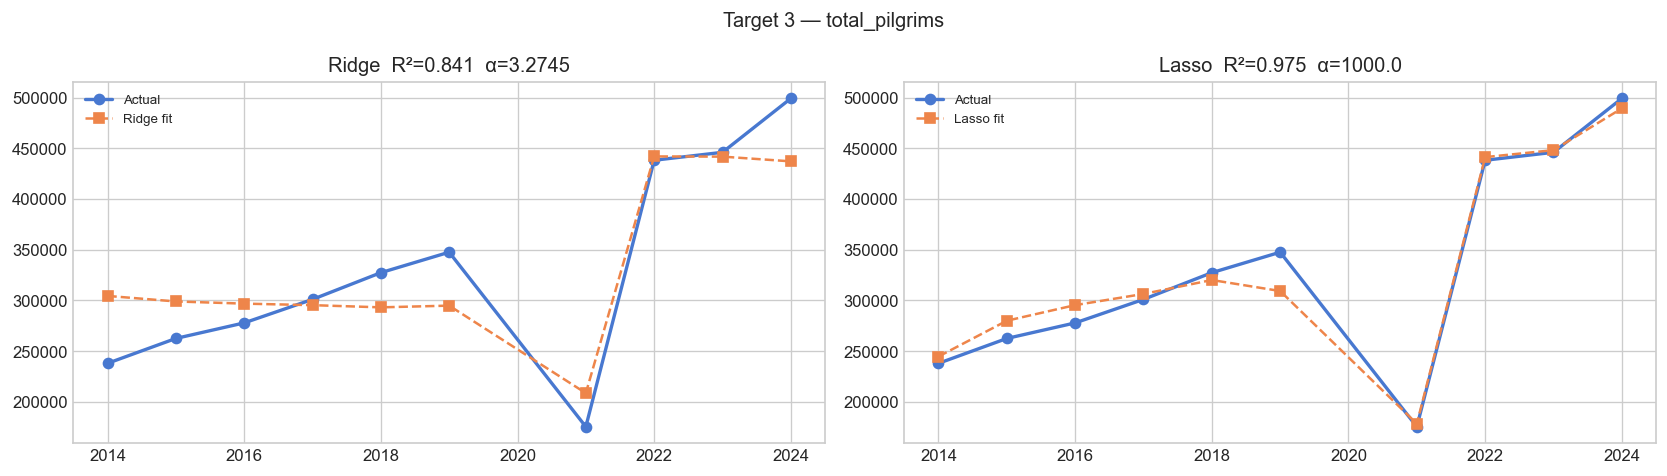

Feature                                          Ridge     Lasso
-----------------------------------------------------------------
  trail_countries_lag1_dt                     5173.9580  -33265.0140
  yoy_growth_lag1                             7740.4765  -56026.3350
  holy_year                                   -33741.5802  -65182.4992
  deferred_demand                             18970.8020    0.0000  ← zeroed
  post_covid_regime                           41668.5394  119930.6007

  n=10  detrend=False
  Ridge  R²=0.841  MAE=31775.0246
  Lasso  R²=0.975  MAE=11068.7575


In [6]:
CANDS_T3 = [
    'yoy_growth_lag1',
    'holy_year',
    'deferred_demand',
    'trail_countries_lag1',
    'post_covid_regime',
]

# Partial detrend: trail only (binary/event features have no _dt version by design)
feats_t3 = get_features(['trail_countries_lag1'], detrend=True) + \
           ['yoy_growth_lag1', 'holy_year', 'deferred_demand', 'post_covid_regime']

res_t3 = run_model('total_pilgrims', feats_t3, detrend=False, n_splits=3)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Target 3 — total_pilgrims', fontsize=12)
plot_model(res_t3, axes[0], axes[1])
plt.tight_layout()
plt.savefig(FIGURES / 'NB04_T3_total.png', dpi=150)
plt.show()

print_coefs(res_t3)

## 6 · Target 4 — `pct_women`

**Priority 4 · Demographic structural signal.**

**Feature selection rationale:**
- `ratio_sequential` excluded — `pct_foot / 100` may be mechanically correlated with `pct_women` if female pilgrims predominantly walk (circular proxy risk)
- `trends_FR_lag0_dt` (r=0.91): French media interest drives new, predominantly female pilgrim profile (NB02 behavioural finding)
- `trends_KR_lag0_dt` (r=0.80): Korean media — strong validated signal (NB02 §4.2)
- `diversity_core_dt` (r=0.97): co-evolution with feminisation — new routes attract new female profiles
- `phase_regime`: 2018+ regime shift coincides with feminisation acceleration (PELT NB02)

**Detrending:** YES — `pct_women` has strong structural upward trend (break at 2018).

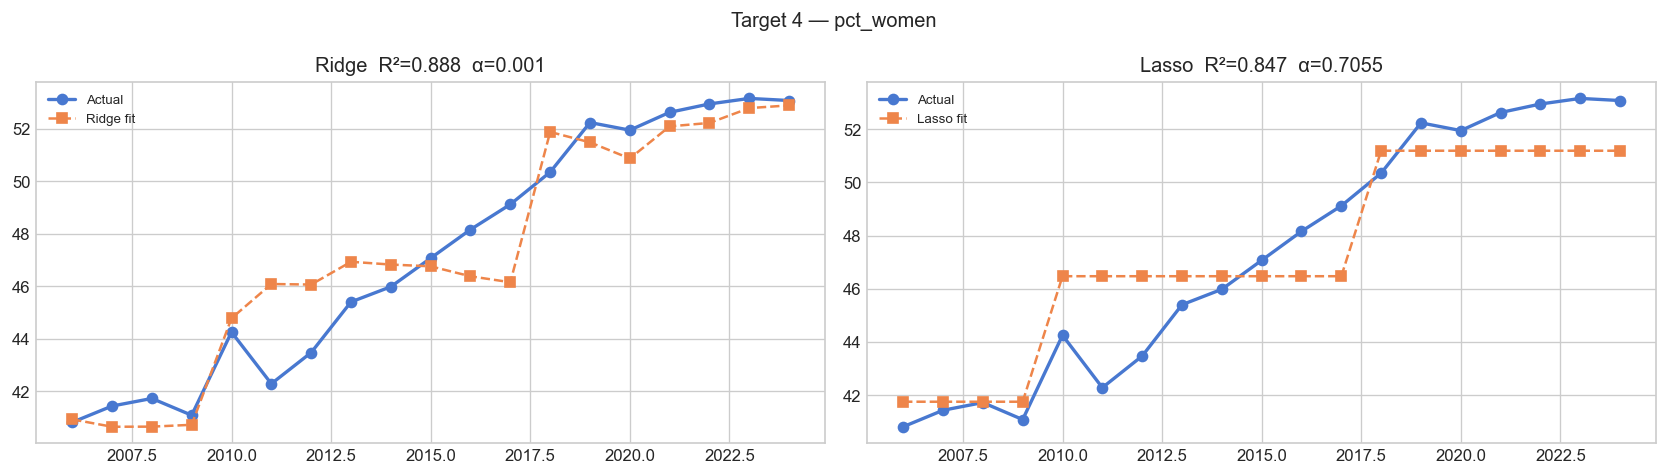

Feature                                          Ridge     Lasso
-----------------------------------------------------------------
  trends_FR_lag0_dt                             0.1621    0.0000  ← zeroed
  trends_KR_lag0_dt                             0.0127    0.0000  ← zeroed
  diversity_core_dt                            -0.6358   -0.0000  ← zeroed
  trends_PT_lag2_dt                             0.1676   -0.0000  ← zeroed
  phase_regime                                  4.4365    3.5137

  n=19  detrend=True
  Ridge  R²=0.888  MAE=1.1519
  Lasso  R²=0.847  MAE=1.4514


In [7]:
CANDS_T4 = [
    'trends_FR_lag0',
    'trends_KR_lag0',
    'diversity_core',
    'trends_PT_lag2',
    'phase_regime',
]

res_t4 = run_model('pct_women', CANDS_T4, detrend=True, n_splits=4)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Target 4 — pct_women', fontsize=12)
plot_model(res_t4, axes[0], axes[1])
plt.tight_layout()
plt.savefig(FIGURES / 'NB04_T4_pct_women.png', dpi=150)
plt.show()

print_coefs(res_t4)

## 7 · Target 5 — `diversity_core`

**Priority 5 · System-level diversification index.**

**Feature selection rationale:**
- `trends_FR_lag0_dt` (r=0.91): French interest drives route exploration beyond Francés
- `accessibility_routes_share` (r=0.89): growth of accessible routes is the primary mechanical driver of diversification — included here as explanatory (not tautological since it is a subset measure, not the same index)
- `trail_countries_lag1_dt` (r=0.60): international reach → diversification spillover
- `phase_regime`: structural phases encode diversification regimes directly

**Detrending:** YES — `diversity_core` has strong structural upward trend.

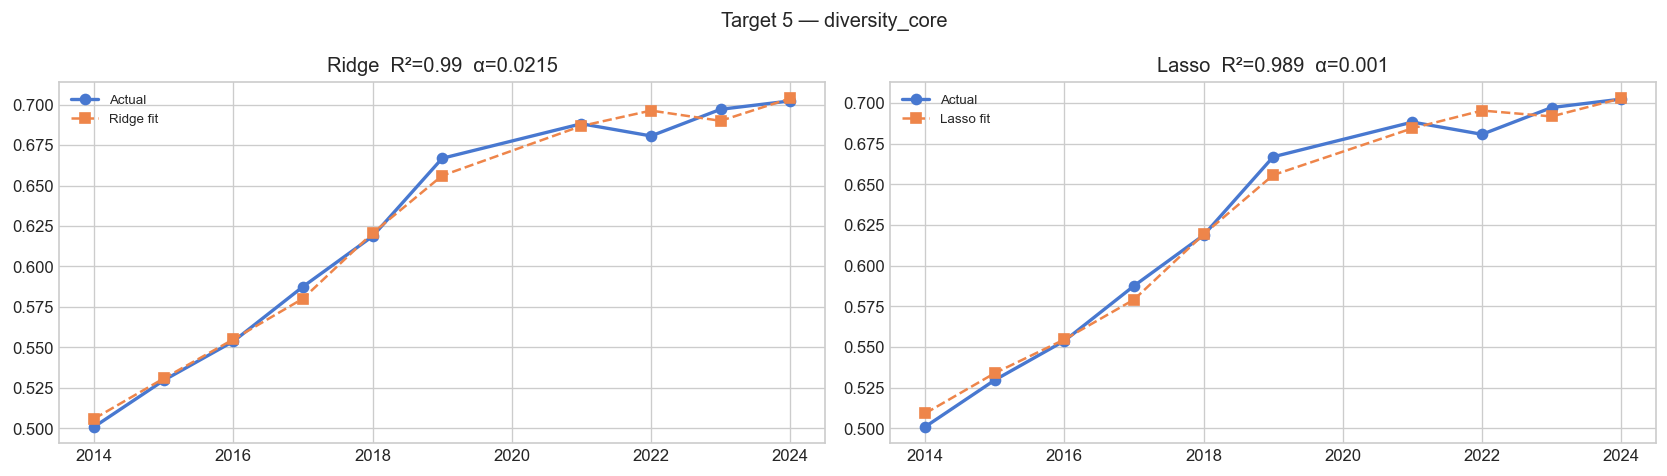

Feature                                          Ridge     Lasso
-----------------------------------------------------------------
  trends_FR_lag0_dt                            -0.0021   -0.0007
  accessibility_routes_share                    0.0683    0.0669
  trail_countries_lag1_dt                      -0.0206   -0.0194
  phase_regime                                  0.0021    0.0023

  n=10  detrend=True
  Ridge  R²=0.99  MAE=0.0053
  Lasso  R²=0.989  MAE=0.0058


In [8]:
CANDS_T5 = [
    'trends_FR_lag0',
    'accessibility_routes_share',
    'trail_countries_lag1',
    'phase_regime',
]

res_t5 = run_model('diversity_core', CANDS_T5, detrend=True, n_splits=3)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Target 5 — diversity_core', fontsize=12)
plot_model(res_t5, axes[0], axes[1])
plt.tight_layout()
plt.savefig(FIGURES / 'NB04_T5_diversity.png', dpi=150)
plt.show()

print_coefs(res_t5)

## 8 · Target 6 — `share_Via_de_la_Plata`

**Priority 6 · Structural decline target — only route with growth index < 100 in 2024.**

**Feature selection rationale:**
- `via_podiensis_fr_summer_temp_lag1_dt` (r=−0.55): the primary climate signal validated in NB02 Axis A — warm French summer → sequential pilgrim avoids southern route
- `accessibility_routes_share` (r=−0.85): accessibility route growth directly substitutes Vía de la Plata (profile displacement)
- `trends_FR_lag0_dt` (r=−0.81): French interest drives new profiles away from the most demanding route
- `trail_countries_lag1_dt` (r=−0.74): global reach → crowd-avoidance on hard routes

**Detrending:** YES for trend-contaminated features. Climate signal kept in both raw and _dt form — test both.

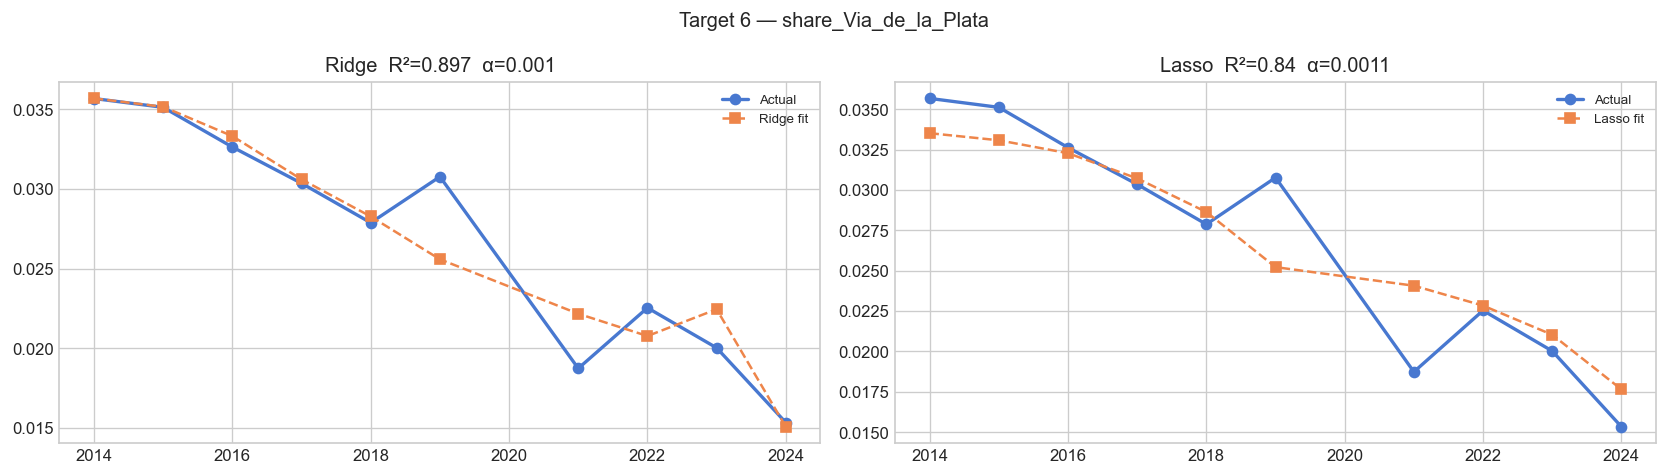

Feature                                          Ridge     Lasso
-----------------------------------------------------------------
  via_podiensis_fr_summer_temp_lag1_dt          0.0007    0.0000  ← zeroed
  accessibility_routes_share                   -0.0068   -0.0053
  trends_FR_lag0_dt                             0.0008    0.0000  ← zeroed
  trail_countries_lag1_dt                       0.0003    0.0000  ← zeroed

  n=10  detrend=True
  Ridge  R²=0.897  MAE=0.0014
  Lasso  R²=0.84  MAE=0.002


In [9]:
CANDS_T6 = [
    'via_podiensis_fr_summer_temp_lag1',
    'accessibility_routes_share',
    'trends_FR_lag0',
    'trail_countries_lag1',
]

res_t6 = run_model('share_Via_de_la_Plata', CANDS_T6, detrend=True, n_splits=3)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Target 6 — share_Via_de_la_Plata', fontsize=12)
plot_model(res_t6, axes[0], axes[1])
plt.tight_layout()
plt.savefig(FIGURES / 'NB04_T6_via_plata.png', dpi=150)
plt.show()

print_coefs(res_t6)

## 9 · Target 7 — `share_challenge`

**Priority 7 · Challenge cluster (Norte + Primitivo + Vía de la Plata).**

**Feature selection rationale:**
- `challenge_routes_share` excluded (r=1.00 — same variable by construction)
- `trail_finishers_lag0_dt` (r=−0.70): trail culture growth → crowd-avoidance on difficult routes paradoxically competes with challenge cluster
- `trail_countries_lag1_dt` (r=−0.68): same mechanism at international scale
- `diversity_core_dt` (r=0.60): diversification favours challenge routes growth
- `trends_DE_lag1_dt` (r=0.17): German interest as counter-indicator (traditional challenge pilgrim profile) — weak signal, kept as test

**Note:** trail features reduce window to n≈10. Interpret with caution.

**Detrending:** YES.

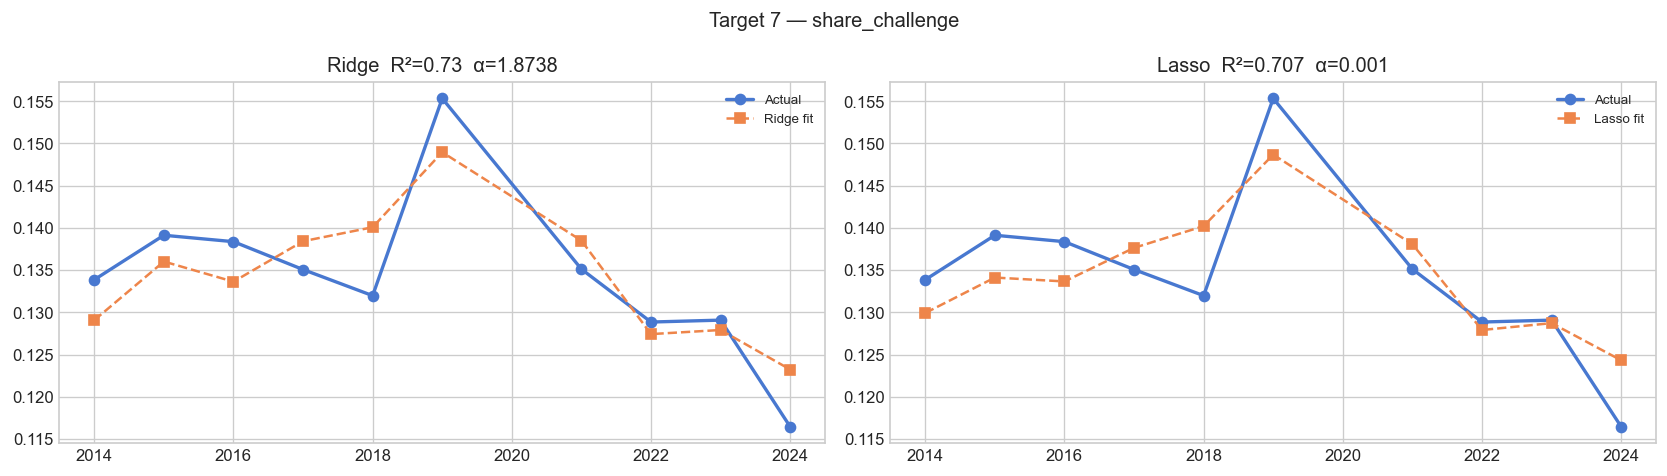

Feature                                          Ridge     Lasso
-----------------------------------------------------------------
  trail_finishers_lag0_dt                      -0.0023   -0.0007
  trail_countries_lag1_dt                       0.0003   -0.0000  ← zeroed
  diversity_core_dt                             0.0034    0.0046
  trends_DE_lag1_dt                             0.0034    0.0024

  n=10  detrend=True
  Ridge  R²=0.73  MAE=0.0043
  Lasso  R²=0.707  MAE=0.0043


In [10]:
CANDS_T7 = [
    'trail_finishers_lag0',
    'trail_countries_lag1',
    'diversity_core',
    'trends_DE_lag1',
]

res_t7 = run_model('share_challenge', CANDS_T7, detrend=True, n_splits=3)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Target 7 — share_challenge', fontsize=12)
plot_model(res_t7, axes[0], axes[1])
plt.tight_layout()
plt.savefig(FIGURES / 'NB04_T7_challenge.png', dpi=150)
plt.show()

print_coefs(res_t7)

## 10 · Synthesis

Comparative summary across all 7 targets: R² vs baseline, feature recurrence, and Lasso zeroing patterns.

In [11]:
all_results = [r for r in [res_t1,res_t2,res_t3,res_t4,res_t5,res_t6,res_t7]
               if r is not None]

# ── 10.1 · R² comparison table ────────────────────────────────────────────────
summary = []
for res in all_results:
    t = res['target']
    summary.append({
        'target'      : t,
        'n'           : res['n'],
        'baseline_R2' : baseline_results.get(t, np.nan),
        'ridge_R2'    : res['ridge_r2'],
        'lasso_R2'    : res['lasso_r2'],
        'ridge_vs_base': round(res['ridge_r2'] - baseline_results.get(t, 0), 3),
        'detrend'     : res['detrend'],
        'features'    : ', '.join(res['features']),
    })

summary_df = pd.DataFrame(summary).set_index('target')
print('── R² summary ──────────────────────────────────────────────────────────')
print(summary_df[['n','baseline_R2','ridge_R2','lasso_R2','ridge_vs_base','detrend']].to_string())

summary_df.to_csv(REPORTS / 'NB04_results.csv')
print('\n✅  NB04_results.csv saved')

── R² summary ──────────────────────────────────────────────────────────
                               n  baseline_R2  ridge_R2  lasso_R2  ridge_vs_base  detrend
target                                                                                   
share_Camino_Portugues_Costa  10        0.715     0.803     0.657          0.088     True
share_Camino_Frances          19        0.938     0.904     0.896         -0.034     True
total_pilgrims                10        0.508     0.841     0.975          0.333    False
pct_women                     19        0.901     0.888     0.847         -0.013     True
diversity_core                10        0.943     0.990     0.989          0.047     True
share_Via_de_la_Plata         10        0.663     0.897     0.840          0.234     True
share_challenge               10        0.236     0.730     0.707          0.494     True

✅  NB04_results.csv saved


In [12]:
# ── 10.2 · Feature recurrence — which features appear most across models ──────
from collections import Counter

feat_counts = Counter(
    f for res in all_results for f in res['features']
)
feat_lasso_active = Counter(
    f for res in all_results
    for f, v in res['lasso_coef'].items() if v != 0
)

recurrence = (
    pd.DataFrame({
        'n_models'     : feat_counts,
        'lasso_active' : feat_lasso_active,
    })
    .fillna(0).astype(int)
    .sort_values('n_models', ascending=False)
)

print('── Feature recurrence ──────────────────────────────────────────────────')
print(recurrence.to_string())

── Feature recurrence ──────────────────────────────────────────────────
                                      n_models  lasso_active
trends_FR_lag0_dt                            5             1
trail_countries_lag1_dt                      5             2
trends_PT_lag2_dt                            3             0
phase_regime                                 3             3
deferred_demand                              2             1
ratio_sequential_dt                          2             0
accessibility_routes_share                   2             2
diversity_core_dt                            2             1
yoy_growth_lag1                              1             1
trends_KR_lag1_dt                            1             0
post_covid_regime                            1             1
holy_year                                    1             1
trends_KR_lag0_dt                            1             0
via_podiensis_fr_summer_temp_lag1_dt         1             0
trail_finish

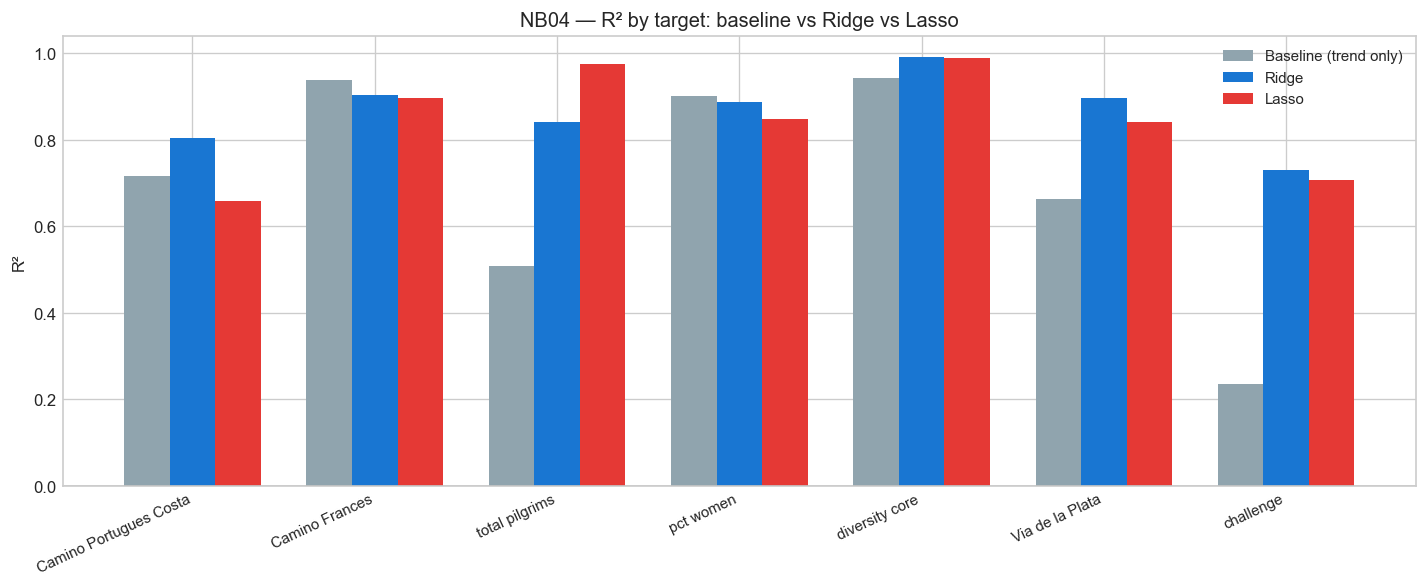

In [13]:
# ── 10.3 · R² vs baseline bar chart ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

x    = np.arange(len(summary_df))
w    = 0.25
lbls = [t.replace('share_','').replace('_',' ') for t in summary_df.index]

ax.bar(x - w,   summary_df['baseline_R2'], w, label='Baseline (trend only)', color='#90A4AE')
ax.bar(x,       summary_df['ridge_R2'],    w, label='Ridge',                 color='#1976D2')
ax.bar(x + w,   summary_df['lasso_R2'],    w, label='Lasso',                 color='#E53935')

ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(lbls, rotation=25, ha='right', fontsize=9)
ax.set_ylabel('R²')
ax.set_title('NB04 — R² by target: baseline vs Ridge vs Lasso', fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES / 'NB04_r2_comparison.png', dpi=150)
plt.show()